#real data

heatmap calculation for overlap in volumetric

Reading data directly from CSV files (no cached data)

Reading CSV file: roi_coordinates_B-cell_infiltration.csv
  Loaded 50 rows from roi_coordinates_B-cell_infiltration.csv

Debug: Column names for roi_coordinates_B-cell_infiltration.csv: ['Model', 'ROI_ID', 'x', 'y', 'z']
First few rows:
  Model  ROI_ID     x     y   z
0   GAT       1  8064  2928  28
1   GAT       2  4104  1456  88
2   GAT       3  6344  2656  86
3   GAT       4  1368  2232  76
4   GAT       5  2600  1168  76

GAT data types:
Model     object
ROI_ID     int64
x          int64
y          int64
z          int64
dtype: object
Sample GAT row:
Model      GAT
ROI_ID       1
x         8064
y         2928
z           28
Name: 0, dtype: object

Reading CSV file: roi_coordinates_Inflammatory_zone.csv
  Loaded 50 rows from roi_coordinates_Inflammatory_zone.csv

Reading CSV file: roi_coordinates_Oxidative_stress_regulation.csv
  Loaded 50 rows from roi_coordinates_Oxidative_stress_regulation.csv

Reading CSV file: roi_coordinat

C:\Users\hosse\AppData\Local\Temp\ipykernel_20568\4283942473.py:761: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.97])


Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\errorbar_grid_all_topics_euclidean_min.png


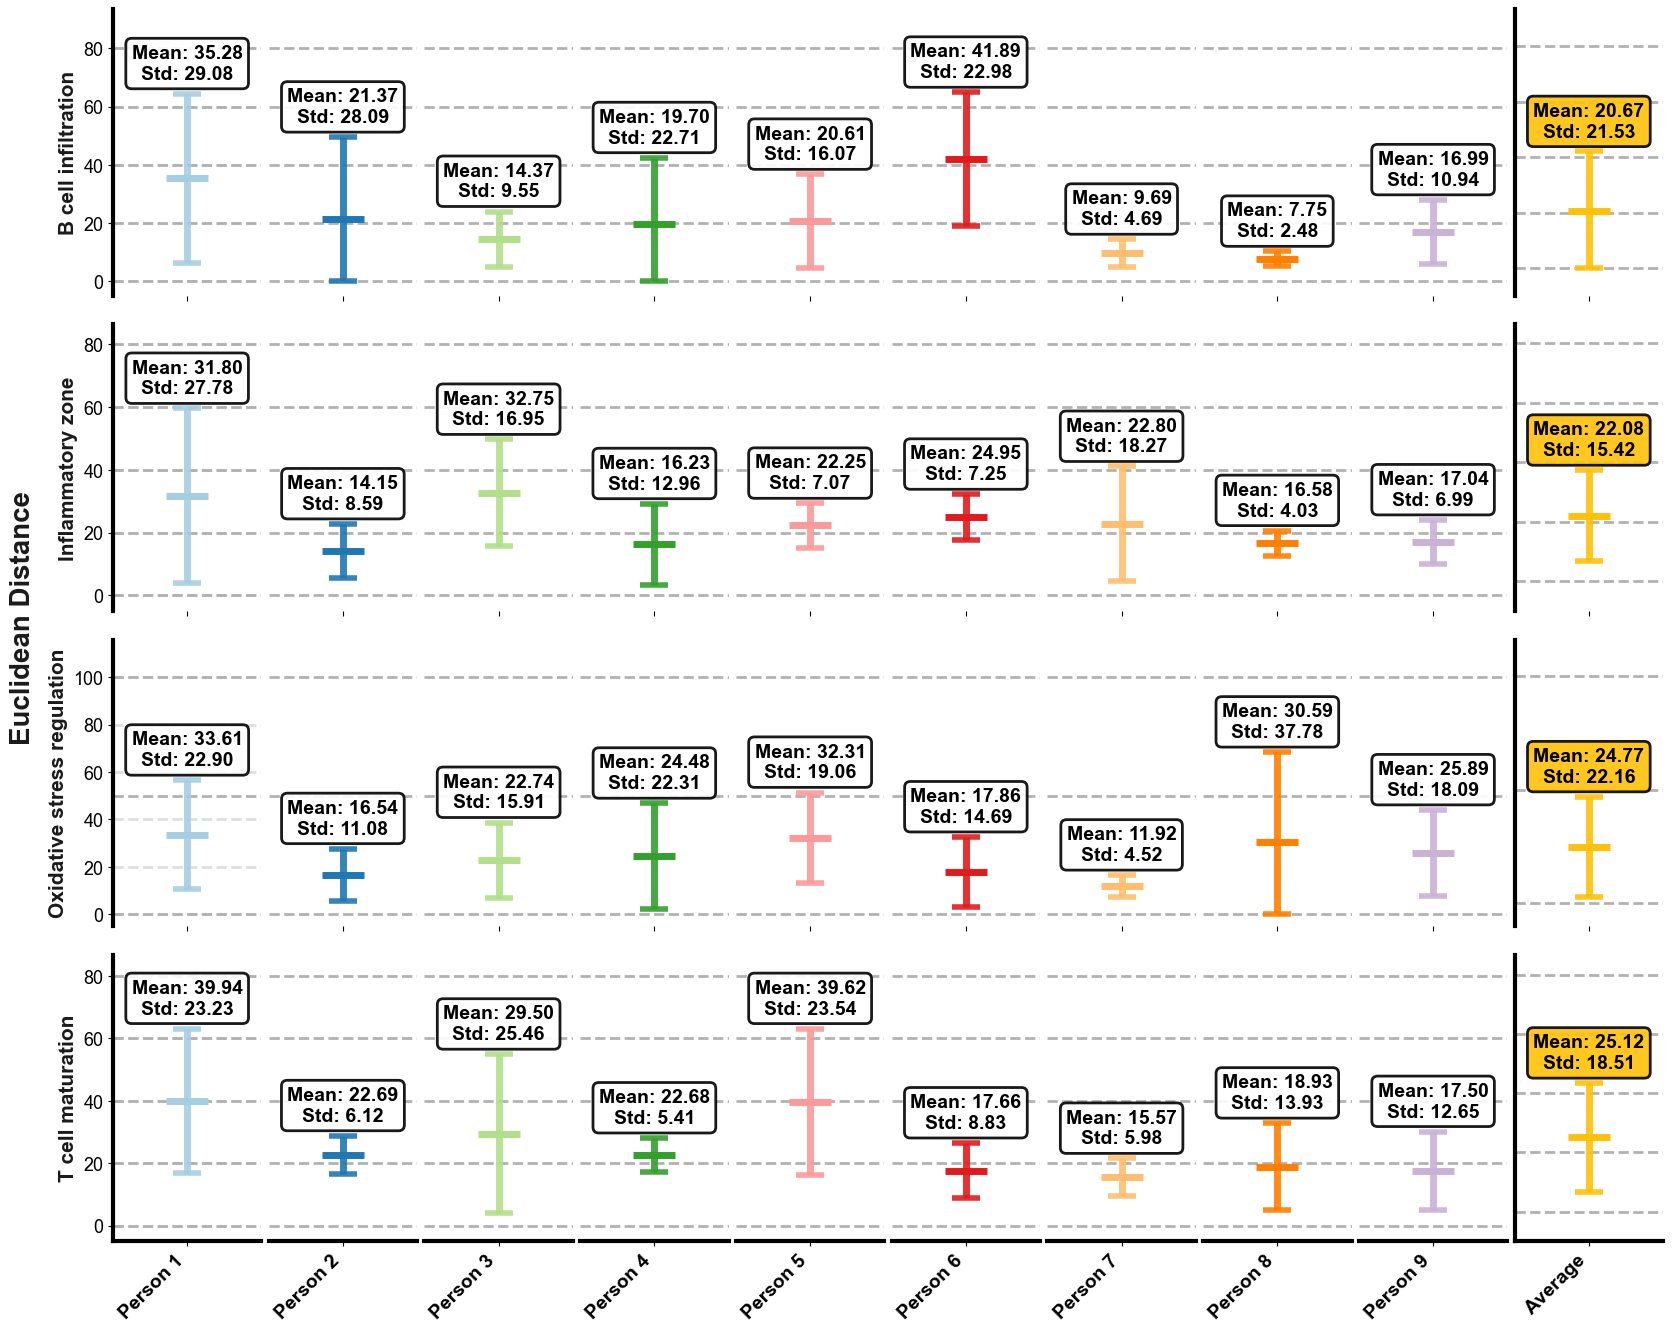

Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\heatmap_euclidean_distance_min.png


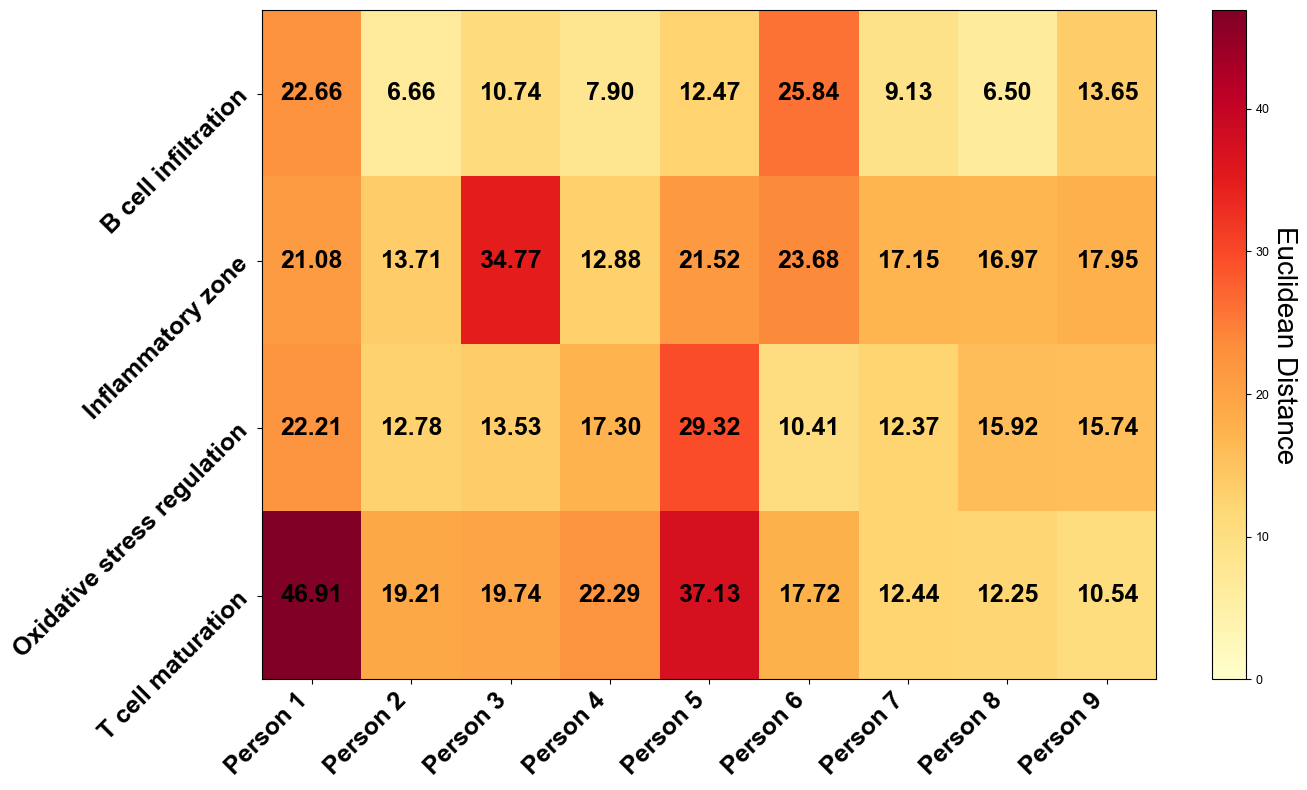

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math

base_dir = Path(r"D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth")
csv_files = [
    'roi_coordinates_B-cell_infiltration.csv',
    'roi_coordinates_Inflammatory_zone.csv',
    'roi_coordinates_Oxidative_stress_regulation.csv',
    'roi_coordinates_T-cell_maturation.csv'
]

SUPERVOXEL_SIZE = 16  # Each supervoxel has 16x16x16 voxels

def euclidean_distance_3d(p1, p2):
    """Calculate 3D Euclidean distance between two points in supervoxel units.
    
    Since each supervoxel has 16x16x16 voxels, we divide the differences by 16
    to get the distance in supervoxel units.
    """
    return math.sqrt(
        ((p2[0] - p1[0]) / SUPERVOXEL_SIZE)**2 + 
        ((p2[1] - p1[1]) / SUPERVOXEL_SIZE)**2 + 
        ((p2[2] - p1[2]) / SUPERVOXEL_SIZE)**2
    )

def remove_outliers(distances, threshold=3.0):
    """Remove outliers that are more than threshold * std from the mean.
    
    Args:
        distances: list of distance values
        threshold: number of standard deviations to use as threshold (default 3.0)
    
    Returns:
        list of distances with outliers removed
    """
    if len(distances) <= 1:
        return distances
    
    distances_array = np.array(distances)
    mean = np.mean(distances_array)
    std = np.std(distances_array)
    
    if std == 0:
        return distances
    
    # Keep only points within threshold * std from mean
    filtered = [d for d in distances if abs(d - mean) <= threshold * std]
    
    # If all points are outliers, return original (shouldn't happen with threshold=3)
    if len(filtered) == 0:
        return distances
    
    return filtered

def calc_min_euclidean_distances(gat_data, person_data):
    """For each person point, find minimum distance to any GAT point"""
    if len(gat_data) == 0 or len(person_data) == 0: 
        return []
    
    # Clean data: remove rows with NaN values and ensure numeric types
    gat_clean = gat_data[['x', 'y', 'z']].copy()
    person_clean = person_data[['x', 'y', 'z']].copy()
    
    # Convert to numeric, coercing errors to NaN
    for col in ['x', 'y', 'z']:
        gat_clean[col] = pd.to_numeric(gat_clean[col], errors='coerce')
        person_clean[col] = pd.to_numeric(person_clean[col], errors='coerce')
    
    # Drop rows with any NaN values
    gat_clean = gat_clean.dropna()
    person_clean = person_clean.dropna()
    
    if len(gat_clean) == 0 or len(person_clean) == 0: 
        return []
    
    # Create list of all GAT points - ensure numeric conversion
    gat_points = []
    for _, row in gat_clean.iterrows():
        x = float(row['x'])
        y = float(row['y'])
        z = float(row['z'])
        if np.isfinite([x, y, z]).all():
            gat_points.append((x, y, z))
    
    if len(gat_points) == 0:
        return []
    
    min_distances = []
    
    # For each person point, calculate distance to all GAT points and find minimum
    for idx, person_row in person_clean.iterrows():
        # Ensure numeric conversion
        px = float(person_row['x'])
        py = float(person_row['y'])
        pz = float(person_row['z'])
        
        # Check if values are finite
        if not np.isfinite([px, py, pz]).all():
            continue
            
        person_point = (px, py, pz)
        
        # Calculate distance from this person point to all GAT points
        distances = []
        for gat_point in gat_points:
            dist = euclidean_distance_3d(person_point, gat_point)
            distances.append(dist)
        
        # Find and store the minimum distance
        if len(distances) == 0:
            continue
            
        min_dist = min(distances)
        min_distances.append(min_dist)
    
    return min_distances

# Process CSV files - ALWAYS read directly from CSV files (no cached data)
results = {}
all_distances = {f'Person {i}': [] for i in range(1, 10)}

print("="*80)
print("Reading data directly from CSV files (no cached data)")
print("="*80)

for csv_filename in csv_files:
    csv_path = base_dir / csv_filename
    if not csv_path.exists():
        print(f"  Warning: CSV file not found: {csv_filename}")
        continue
    
    # Always read fresh from CSV (no caching)
    print(f"\nReading CSV file: {csv_filename}")
    df = pd.read_csv(csv_path)
    print(f"  Loaded {len(df)} rows from {csv_filename}")
    sheet_name = csv_filename.replace('roi_coordinates_', '').replace('.csv', '')
    
    # Debug: Print column names (only for first file)
    if csv_filename == csv_files[0]:
        print(f"\nDebug: Column names for {csv_filename}: {df.columns.tolist()}")
        print(f"First few rows:\n{df.head()}")
    
    # Filter GAT data - ensure we get exact match (case-sensitive)
    gat_data = df[df.iloc[:, 0] == 'GAT'].copy()
    
    # Clean GAT data: remove rows with NaN in coordinates
    gat_data = gat_data.dropna(subset=['x', 'y', 'z'])
    # Convert to numeric
    for col in ['x', 'y', 'z']:
        gat_data[col] = pd.to_numeric(gat_data[col], errors='coerce')
    gat_data = gat_data.dropna(subset=['x', 'y', 'z'])
    gat_data = gat_data.sort_values(by='ROI_ID').reset_index(drop=True)
    
    if len(gat_data) == 0:
        print(f"  Warning: No valid GAT data found in {sheet_name}")
        continue
    
    # Debug: Verify data types (only for first file)
    if csv_filename == csv_files[0] and len(gat_data) > 0:
        print(f"\nGAT data types:\n{gat_data.dtypes}")
        print(f"Sample GAT row:\n{gat_data.iloc[0]}")
    
    results[sheet_name] = {}
    
    for person_num in range(1, 10):
        person_name = f'Person {person_num}'
        person_data = df[df.iloc[:, 0] == person_name].copy()
        
        # Clean person data: remove rows with NaN in coordinates
        person_data = person_data.dropna(subset=['x', 'y', 'z'])
        # Convert to numeric
        for col in ['x', 'y', 'z']:
            person_data[col] = pd.to_numeric(person_data[col], errors='coerce')
        person_data = person_data.dropna(subset=['x', 'y', 'z'])
        person_data = person_data.sort_values(by='ROI_ID').reset_index(drop=True)
        
        if len(person_data) == 0:
            print(f"  Warning: No valid data found for {person_name} in {sheet_name}")
            continue
        
        distances_raw = calc_min_euclidean_distances(gat_data, person_data)
        
        if len(distances_raw) > 0:
            # Remove outliers (points with distance > 3*std from mean)
            distances = remove_outliers(distances_raw, threshold=3.0)
            
            outliers_removed = len(distances_raw) - len(distances)
            if outliers_removed > 0:
                print(f"  {sheet_name} - {person_name}: Removed {outliers_removed} outlier(s)")
                print(f"    Original distances: {[f'{d:.4f}' for d in distances_raw]}")
                print(f"    Filtered distances: {[f'{d:.4f}' for d in distances]}")
            
            min_dist = np.min(distances)
            mean_dist = np.mean(distances)
            
            # Check for zero or very small distances
            if min_dist < 0.001:
                print(f"WARNING: {sheet_name} - {person_name} has very small minimum distance: {min_dist:.6f}")
                print(f"  All distances: {[f'{d:.6f}' for d in distances]}")
                print(f"  GAT points: {[(row['x'], row['y'], row['z']) for _, row in gat_data.iterrows()]}")
                print(f"  Person points: {[(row['x'], row['y'], row['z']) for _, row in person_data.iterrows()]}")
            
            results[sheet_name][person_name] = {
                'distances_raw': distances_raw,  # Keep raw distances for reference
                'distances': distances,  # Filtered distances (outliers removed)
                'outliers_removed': outliers_removed,
                'mean': mean_dist,
                'median': np.median(distances),
                'std': np.std(distances),
                'min': min_dist,
                'max': np.max(distances)
            }
            all_distances[person_name].extend(distances)

print("\n" + "="*80)
print("✓ All CSV files processed - data read directly from CSV files (no cached data)")
print("="*80)

# Detailed analysis for Person 6 and Inflammatory_zone
print("\n" + "="*80)
print("DETAILED ANALYSIS: Person 6 - Inflammatory_zone")
print("="*80)

csv_path_inflam = base_dir / 'roi_coordinates_Inflammatory_zone.csv'
if csv_path_inflam.exists():
    # Always read fresh from CSV (no caching)
    print(f"\nReading CSV file for detailed analysis: roi_coordinates_Inflammatory_zone.csv")
    df_inflam = pd.read_csv(csv_path_inflam)
    print(f"  Loaded {len(df_inflam)} rows from CSV")
    gat_data_inflam = df_inflam[df_inflam.iloc[:, 0] == 'GAT'].copy().sort_values(by='ROI_ID').reset_index(drop=True)
    person6_data_inflam = df_inflam[df_inflam.iloc[:, 0] == 'Person 6'].copy().sort_values(by='ROI_ID').reset_index(drop=True)
    
    print(f"\nGAT points ({len(gat_data_inflam)} points):")
    for idx, row in gat_data_inflam.iterrows():
        print(f"  ROI_ID {row['ROI_ID']}: x={row['x']}, y={row['y']}, z={row['z']}")
    
    print(f"\nPerson 6 points ({len(person6_data_inflam)} points):")
    for idx, row in person6_data_inflam.iterrows():
        print(f"  ROI_ID {row['ROI_ID']}: x={row['x']}, y={row['y']}, z={row['z']}")
    
    # Calculate distances for each Person 6 point
    print(f"\nDetailed distance calculations (in supervoxel units, 1 supervoxel = 16x16x16 voxels):")
    all_min_distances_p6 = []
    for idx, person_row in person6_data_inflam.iterrows():
        px = float(person_row['x'])
        py = float(person_row['y'])
        pz = float(person_row['z'])
        person_point = (px, py, pz)
        
        print(f"\n  Person 6, ROI_ID {person_row['ROI_ID']}: ({px}, {py}, {pz})")
        
        distances_to_all_gat = []
        for gat_idx, gat_row in gat_data_inflam.iterrows():
            gx = float(gat_row['x'])
            gy = float(gat_row['y'])
            gz = float(gat_row['z'])
            gat_point = (gx, gy, gz)
            
            dist = euclidean_distance_3d(person_point, gat_point)
            distances_to_all_gat.append(dist)
            print(f"    Distance to GAT ROI_ID {gat_row['ROI_ID']} ({gx}, {gy}, {gz}): {dist:.6f}")
        
        min_dist = min(distances_to_all_gat)
        max_dist = max(distances_to_all_gat)
        all_min_distances_p6.append(min_dist)
        
        print(f"    ---> MINIMUM distance: {min_dist:.6f}")
        print(f"    ---> MAXIMUM distance: {max_dist:.6f}")
    
    print(f"\n" + "-"*80)
    print(f"SUMMARY for Person 6 - Inflammatory_zone (in supervoxel units, 1 supervoxel = 16x16x16 voxels):")
    print(f"  All minimum distances (raw): {[f'{d:.6f}' for d in all_min_distances_p6]}")
    
    # Apply outlier removal
    filtered_distances_p6 = remove_outliers(all_min_distances_p6, threshold=3.0)
    outliers_removed_p6 = len(all_min_distances_p6) - len(filtered_distances_p6)
    
    if outliers_removed_p6 > 0:
        print(f"  Outliers removed: {outliers_removed_p6}")
        print(f"  Filtered distances: {[f'{d:.6f}' for d in filtered_distances_p6]}")
    
    print(f"  Overall MINIMUM: {min(filtered_distances_p6):.6f}")
    print(f"  Overall MAXIMUM: {max(filtered_distances_p6):.6f}")
    print(f"  Mean: {np.mean(filtered_distances_p6):.6f}")
    print(f"  Median: {np.median(filtered_distances_p6):.6f}")
    print(f"  Std: {np.std(filtered_distances_p6):.6f}")
    
    # Check if this matches the results dictionary
    if 'Inflammatory_zone' in results and 'Person 6' in results['Inflammatory_zone']:
        stats = results['Inflammatory_zone']['Person 6']
        print(f"\nFrom results dictionary (filtered, supervoxel units):")
        print(f"  Min: {stats['min']:.6f}")
        print(f"  Max: {stats['max']:.6f}")
        print(f"  Mean: {stats['mean']:.6f}")
        print(f"  Outliers removed: {stats.get('outliers_removed', 0)}")
        if abs(min(filtered_distances_p6) - stats['min']) > 0.001:
            print(f"  *** MISMATCH in MIN: calculated={min(filtered_distances_p6):.6f}, dictionary={stats['min']:.6f}")
        if abs(max(filtered_distances_p6) - stats['max']) > 0.001:
            print(f"  *** MISMATCH in MAX: calculated={max(filtered_distances_p6):.6f}, dictionary={stats['max']:.6f}")
    
print("="*80)

# Print detailed debug information for Person 3 and Person 6
print("="*60)
print("Debug: Detailed distance calculations for Person 3 and Person 6")
print("="*60)
for csv_filename in csv_files:  # All files
    csv_path = base_dir / csv_filename
    if not csv_path.exists():
        print(f"  Warning: CSV file not found: {csv_filename}")
        continue
    
    # Always read fresh from CSV (no caching)
    print(f"\nReading CSV file for debug: {csv_filename}")
    df = pd.read_csv(csv_path)
    print(f"  Loaded {len(df)} rows from CSV")
    sheet_name = csv_filename.replace('roi_coordinates_', '').replace('.csv', '')
    gat_data = df[df.iloc[:, 0] == 'GAT'].copy().sort_values(by='ROI_ID').reset_index(drop=True)
    
    # Check Person 3 and Person 6 specifically
    for person_check in ['Person 3', 'Person 6']:
        person_data = df[df.iloc[:, 0] == person_check].copy().sort_values(by='ROI_ID').reset_index(drop=True)
        if len(person_data) == 0:
            continue
            
        print(f"\n{sheet_name} - {person_check}:")
        print(f"GAT points:")
        for idx, row in gat_data.iterrows():
            print(f"  ROI_ID {row['ROI_ID']}: ({row['x']}, {row['y']}, {row['z']})")
        
        print(f"\n{person_check} points:")
        for idx, row in person_data.iterrows():
            print(f"  ROI_ID {row['ROI_ID']}: ({row['x']}, {row['y']}, {row['z']})")
        
        # Calculate distances for all person points
        print(f"\nDetailed calculations for {person_check}:")
        all_min_distances = []
        for p_idx, person_row in person_data.iterrows():
            person_point = (float(person_row['x']), float(person_row['y']), float(person_row['z']))
            print(f"  Person ROI_ID {person_row['ROI_ID']} point: {person_point}")
            distances_to_gat = []
            for idx, gat_row in gat_data.iterrows():
                gat_point = (float(gat_row['x']), float(gat_row['y']), float(gat_row['z']))
                dist = euclidean_distance_3d(person_point, gat_point)
                distances_to_gat.append(dist)
                print(f"    Distance to GAT ROI_ID {gat_row['ROI_ID']} {gat_point}: {dist:.6f}")
            min_dist = min(distances_to_gat)
            all_min_distances.append(min_dist)
            print(f"    MINIMUM distance: {min_dist:.6f}")
            print()
        
        if sheet_name in results and person_check in results[sheet_name]:
            dists = results[sheet_name][person_check]['distances']
            print(f"Results summary from calculation:")
            print(f"  Number of distances: {len(dists)}")
            print(f"  All distances: {[f'{d:.6f}' for d in dists]}")
            print(f"  Mean: {results[sheet_name][person_check]['mean']:.6f}")
            print(f"  Min: {results[sheet_name][person_check]['min']:.6f}")
            print(f"  Max: {results[sheet_name][person_check]['max']:.6f}")
            
            # Compare with manual calculation
            print(f"Manual calculation distances: {[f'{d:.6f}' for d in all_min_distances]}")
            if len(dists) == len(all_min_distances):
                for i, (calc_dist, manual_dist) in enumerate(zip(dists, all_min_distances)):
                    if abs(calc_dist - manual_dist) > 0.01:
                        print(f"  WARNING: Mismatch at index {i}: calculated={calc_dist:.6f}, manual={manual_dist:.6f}")
print("="*60)

# Print summary for all results to verify calculations
print("\n" + "="*60)
print("Summary of all calculated distances (ORIGINAL VALUES - NO DIVISION):")
print("="*60)
zero_count = 0
for sheet_name in sorted(results.keys()):
    print(f"\n{sheet_name}:")
    for person_name in sorted(results[sheet_name].keys()):
        stats = results[sheet_name][person_name]
        mean_before = stats['mean']
        min_before = stats['min']
        # Note: No division applied - showing original values
        mean_after = mean_before  # Same as original
        min_after = min_before  # Same as original
        
        # Check for zero or suspiciously small values
        if min_before < 0.001:
            print(f"  *** {person_name}: Mean={mean_before:.6f}, "
                  f"Min={min_before:.6f} (ZERO/SUSPICIOUS!), Max={stats['max']:.2f}, Count={len(stats['distances'])}")
            print(f"      All distances: {[f'{d:.6f}' for d in stats['distances']]}")
            zero_count += 1
        else:
            print(f"  {person_name}: Mean={mean_before:.2f}, "
                  f"Min={min_before:.2f}, Max={stats['max']:.2f}, Count={len(stats['distances'])}")
if zero_count > 0:
    print(f"\n*** WARNING: Found {zero_count} cases with zero or suspiciously small minimum distances!")
else:
    print(f"\n✓ All minimum distances are non-zero (>= 0.001)")
print("="*60)

# Print MIN and MAX for each person and microenvironment in a clear format
print("\n" + "="*80)
print("MIN and MAX Euclidean Distances for Each Person and Microenvironment")
print("="*80)
print("\nFormat: MIN | MAX (both in original units, before division by 16)")
print("-"*80)

for sheet_name in sorted(results.keys()):
    print(f"\n{sheet_name.replace('_', ' ').replace('-', ' ').title()}:")
    print(f"  {'Person':<12} {'MIN':<18} {'MAX':<18}")
    print(f"  {'-'*12} {'-'*18} {'-'*18}")
    for person_name in sorted(results[sheet_name].keys()):
        stats = results[sheet_name][person_name]
        min_val = stats['min']
        max_val = stats['max']
        print(f"  {person_name:<12} {min_val:>17.2f} {max_val:>17.2f}")

print("\n" + "="*80)

person_names = [f'Person {i}' for i in range(1, 10)]
# Better color palette - more vibrant and distinct
person_colors = ['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c', '#fb9a99', '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6']
topics_list = list(results.keys())

# ============================================================================
# OUTLIER REMOVAL PER MICROENVIRONMENT (before plotting)
# Remove points where distance > 2*std from the mean of each microenvironment
# ============================================================================
print("\n" + "="*80)
print("OUTLIER REMOVAL PER MICROENVIRONMENT (threshold = 2*std)")
print("="*80)

OUTLIER_THRESHOLD = 2.0  # Number of standard deviations for outlier detection

# Create filtered results
results_filtered = {}

for sheet_name in topics_list:
    # First, collect all distances for this microenvironment
    all_distances_topic = []
    for person_name in person_names:
        if person_name in results[sheet_name] and len(results[sheet_name][person_name]['distances']) > 0:
            all_distances_topic.extend(results[sheet_name][person_name]['distances'])
    
    if len(all_distances_topic) == 0:
        results_filtered[sheet_name] = results[sheet_name]
        continue
    
    # Calculate mean and std for this microenvironment
    topic_mean = np.mean(all_distances_topic)
    topic_std = np.std(all_distances_topic)
    
    print(f"\n{sheet_name}:")
    print(f"  All distances count: {len(all_distances_topic)}")
    print(f"  Microenvironment Mean: {topic_mean:.4f}, Std: {topic_std:.4f}")
    print(f"  Outlier threshold: |distance - {topic_mean:.4f}| > {OUTLIER_THRESHOLD} * {topic_std:.4f} = {OUTLIER_THRESHOLD * topic_std:.4f}")
    
    results_filtered[sheet_name] = {}
    
    total_outliers_topic = 0
    for person_name in person_names:
        if person_name in results[sheet_name] and len(results[sheet_name][person_name]['distances']) > 0:
            original_distances = results[sheet_name][person_name]['distances']
            
            # Filter distances based on microenvironment std
            if topic_std > 0:
                filtered_distances = [d for d in original_distances 
                                     if abs(d - topic_mean) <= OUTLIER_THRESHOLD * topic_std]
            else:
                filtered_distances = original_distances
            
            outliers_removed = len(original_distances) - len(filtered_distances)
            total_outliers_topic += outliers_removed
            
            if outliers_removed > 0:
                removed_values = [d for d in original_distances if d not in filtered_distances]
                print(f"  {person_name}: Removed {outliers_removed} outlier(s): {[f'{d:.2f}' for d in removed_values]}")
            
            # Recalculate stats with filtered distances
            if len(filtered_distances) > 0:
                results_filtered[sheet_name][person_name] = {
                    'distances_raw': results[sheet_name][person_name].get('distances_raw', original_distances),
                    'distances': filtered_distances,
                    'outliers_removed': outliers_removed,
                    'mean': np.mean(filtered_distances),
                    'median': np.median(filtered_distances),
                    'std': np.std(filtered_distances),
                    'min': np.min(filtered_distances),
                    'max': np.max(filtered_distances)
                }
            else:
                # If all points are outliers, keep original (shouldn't happen)
                results_filtered[sheet_name][person_name] = results[sheet_name][person_name]
        elif person_name in results[sheet_name]:
            results_filtered[sheet_name][person_name] = results[sheet_name][person_name]
    
    print(f"  Total outliers removed in {sheet_name}: {total_outliers_topic}")

# Use filtered results for plotting
results = results_filtered
print("\n" + "="*80)
print("Using filtered results for plotting (outliers removed)")
print("="*80)

# Set better font settings
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 14

# Calculate max distance for x-axis limits (no division - use original values)
max_distance = 0
all_max_values = []
for sheet_name in topics_list:
    for person_name in person_names:
        if person_name in results[sheet_name] and len(results[sheet_name][person_name]['distances']) > 0:
            person_max = results[sheet_name][person_name]['max']
            all_max_values.append(person_max)
            max_distance = max(max_distance, person_max)

# Debug: Print all max values to identify outliers
print(f"\nDebug: All max values from results:")
for sheet_name in topics_list:
    for person_name in person_names:
        if person_name in results[sheet_name] and len(results[sheet_name][person_name]['distances']) > 0:
            stats = results[sheet_name][person_name]
            print(f"  {sheet_name} - {person_name}: max={stats['max']:.2f}, mean={stats['mean']:.2f}, std={stats['std']:.2f}")

# Use actual maximum from all distances, not from stats['max'] which might be incorrect
max_distance_actual = 0
for sheet_name in topics_list:
    for person_name in person_names:
        if person_name in results[sheet_name] and len(results[sheet_name][person_name]['distances']) > 0:
            distances = results[sheet_name][person_name]['distances']
            max_distance_actual = max(max_distance_actual, np.max(distances))

print(f"\nDebug: max_distance from stats['max'] = {max_distance:.2f}")
print(f"Debug: max_distance_actual from np.max(distances) = {max_distance_actual:.2f}")

# Calculate max distance for each microenvironment (110% of actual max in each category)
max_per_topic = {}
for sheet_name in topics_list:
    topic_max = 0
    for person_name in person_names:
        if person_name in results[sheet_name] and len(results[sheet_name][person_name]['distances']) > 0:
            stats = results[sheet_name][person_name]
            # Consider mean + std as the visual maximum (top of error bar)
            visual_max = stats['mean'] + stats['std']
            topic_max = max(topic_max, visual_max, stats['max'])
    # Add 10% margin to the maximum
    max_per_topic[sheet_name] = topic_max * 1.10

print(f"\nDebug: Maximum per microenvironment (with 10% margin):")
for sheet_name, max_val in max_per_topic.items():
    print(f"  {sheet_name}: {max_val:.2f}")
print(f"Using per-microenvironment y-axis limits (110% of max)")

if len(topics_list) > 0:
    # Grid: rows = topics (microenvironments), columns = persons + average
    num_topics = len(topics_list)
    num_cols = len(person_names) + 1  # +1 for average column
    fig = plt.figure(figsize=(20, 4 * num_topics))
    gs = fig.add_gridspec(num_topics, num_cols, hspace=0.1, wspace=0.05)  # Reduced hspace and wspace for closer spacing

    for row_idx, sheet_name in enumerate(topics_list):
        all_topic_distances = []
        
        # Get the y_max for this microenvironment (110% of max in this category)
        y_max_topic = max_per_topic[sheet_name]
        
        # Calculate mean for this microenvironment (for horizontal dash line)
        microenvironment_means = []
        for person_name in person_names:
            if person_name in results[sheet_name] and len(results[sheet_name][person_name]['distances']) > 0:
                microenvironment_means.append(results[sheet_name][person_name]['mean'])  # No division
        microenvironment_mean = np.mean(microenvironment_means) if len(microenvironment_means) > 0 else 0
        
        # Plot each person in columns
        for col_idx, person_name in enumerate(person_names):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            
            if person_name in results[sheet_name]:
                distances = results[sheet_name][person_name]['distances']
                if len(distances) > 0:
                    all_topic_distances.extend(distances)
                    stats = results[sheet_name][person_name]
                    # Use original values (no division) - using mean
                    mean_val = stats['mean']
                    std_val = stats['std']
                    
                    # Debug print for all values going to plot
                    if sheet_name == 'Inflammatory_zone' and person_name == 'Person 6':
                        print(f"\nDEBUG PLOT VALUES - {sheet_name} - {person_name}:")
                        print(f"  Original stats - mean: {stats['mean']:.6f}, median: {stats['median']:.6f}, std: {stats['std']:.6f}, min: {stats['min']:.6f}, max: {stats['max']:.6f}")
                        print(f"  Using original values - mean_val: {mean_val:.6f}, std_val: {std_val:.6f}")
                        print(f"  *** ACTUAL MINIMUM: {stats['min']:.6f} (NOT ZERO!)")
                        print(f"  *** ACTUAL MAXIMUM: {stats['max']:.6f}")
                        print(f"  Note: Error bar may reach zero when std > mean, but actual min distance is {stats['min']:.6f}")
                    
                    # Create error bar plot (vertical, similar to inter-rater plot)
                    x_pos = 0.5
                    color = person_colors[col_idx]
                    
                    # Error bar (vertical line with caps) - thicker lines
                    # Limit error bar to minimum 0 (mean - std cannot be negative)
                    # yerr_lower should be the distance from mean to (mean - std), but not exceed mean itself
                    # So if std > mean, yerr_lower = mean, otherwise yerr_lower = std
                    yerr_lower = min(std_val, mean_val)  # Ensure error bar doesn't go below 0
                    
                    # Debug: Print what the error bar range will be
                    if sheet_name == 'Inflammatory_zone' and person_name == 'Person 6':
                        error_bar_bottom = mean_val - yerr_lower
                        error_bar_top = mean_val + std_val
                        print(f"  yerr_lower: {yerr_lower:.6f}, std_val: {std_val:.6f}")
                        print(f"  Error bar range: bottom={error_bar_bottom:.6f}, mean={mean_val:.6f}, top={error_bar_top:.6f}")
                        print(f"  Plotting: x_pos={x_pos}, mean_val={mean_val:.6f}, yerr=([{yerr_lower:.6f}], [{std_val:.6f}])")
                    
                    ax.errorbar(x_pos, mean_val, yerr=([yerr_lower], [std_val]), fmt='none', color=color, 
                               capsize=10, capthick=4, linewidth=5, alpha=0.9, elinewidth=5)
                    # Point estimate (horizontal line marker) - thicker
                    ax.plot(x_pos, mean_val, marker='_', color=color, markersize=30, 
                           markeredgewidth=5, alpha=1.0, linewidth=6)
                    
                    # Configurable offset for text box above bar (as percentage of y_max_topic)
                    TEXT_OFFSET_RATIO = 0.04  # 4% of y_max as offset (reduced for less distance)
                    error_bar_top = mean_val + std_val
                    text_y_pos = error_bar_top + (y_max_topic * TEXT_OFFSET_RATIO)
                    
                    stats_text = f"Mean: {mean_val:.2f}\nStd: {std_val:.2f}"
                    ax.text(x_pos, text_y_pos, stats_text,
                           ha='center', va='bottom', fontsize=14, fontweight='bold',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black', linewidth=2))
                else:
                    # Empty plot
                    ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                           ha='center', va='center', fontsize=12, color='gray')
            else:
                # Empty plot
                ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                       ha='center', va='center', fontsize=12, color='gray')
            
            # Adjust ylim to accommodate text boxes above bars (use y_max_topic for this microenvironment)
            ax.set_ylim(-5, y_max_topic)
            ax.set_xlim(0, 1)
            ax.set_xticks([0.5])
            ax.set_xticklabels([person_name], rotation=45, ha='right', fontsize=14, fontweight='bold')
            ax.grid(True, alpha=0.4, axis='y', linestyle='--', linewidth=2)
            
            # Add horizontal dash lines at appropriate intervals (based on y_max_topic)
            # Calculate appropriate interval based on y_max_topic
            if y_max_topic > 100:
                interval = 50
            elif y_max_topic > 50:
                interval = 20
            elif y_max_topic > 20:
                interval = 10
            else:
                interval = 5
            dash_intervals = [i * interval for i in range(int(y_max_topic / interval) + 1)]
            for y_val in dash_intervals:
                if y_val <= y_max_topic:
                    ax.axhline(y=y_val, color='gray', linestyle='--', linewidth=2, alpha=0.6, zorder=0)
            
            ax.tick_params(axis='x', labelsize=14, colors='black')
            ax.tick_params(axis='y', labelsize=13, colors='black')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(3)
            ax.spines['bottom'].set_linewidth(3)
            if row_idx < num_topics - 1:
                ax.spines['bottom'].set_visible(False)
            if col_idx > 0:
                ax.spines['left'].set_visible(False)
            
            if col_idx == 0:
                full_name = sheet_name.replace('_', ' ').replace('-', ' ')
                ax.set_ylabel(full_name, fontsize=15, fontweight='bold', color='#1a1a1a')
            else:
                ax.set_ylabel('')
                ax.set_yticks([])
            
            # Remove xlabel - person names in xticklabels are enough
            if row_idx < num_topics - 1:
                ax.set_xticklabels([])
        
        # Plot average in last column (using mean)
        ax_avg = fig.add_subplot(gs[row_idx, num_cols - 1])
        if len(all_topic_distances) > 0:
            # Use original values (no division) - using mean
            mean_avg = np.mean(all_topic_distances)
            std_avg = np.std(all_topic_distances)
            x_pos_avg = 0.5
            
            # Error bar for average (vertical) - thicker lines
            # Limit error bar to minimum 0 (mean - std cannot be negative)
            yerr_lower_avg = min(std_avg, mean_avg)  # Ensure error bar doesn't go below 0
            ax_avg.errorbar(x_pos_avg, mean_avg, yerr=([yerr_lower_avg], [std_avg]), fmt='none', color='#FFC107', 
                           capsize=10, capthick=4, linewidth=5, alpha=0.9, elinewidth=5)
            ax_avg.plot(x_pos_avg, mean_avg, marker='_', color='#FFC107', markersize=30, 
                       markeredgewidth=5, alpha=1.0, linewidth=6)
            
            # Configurable offset for text box above average bar (as percentage of y_max_topic)
            TEXT_OFFSET_RATIO_AVG = 0.04  # 4% of y_max as offset (reduced for less distance)
            error_bar_top_avg = mean_avg + std_avg
            text_y_pos_avg = error_bar_top_avg + (y_max_topic * TEXT_OFFSET_RATIO_AVG)
            
            stats_text = f"Mean: {mean_avg:.2f}\nStd: {std_avg:.2f}"
            ax_avg.text(x_pos_avg, text_y_pos_avg, stats_text,
                       ha='center', va='bottom', fontsize=14, fontweight='bold',
                       bbox=dict(boxstyle='round', facecolor='#FFC107', alpha=0.9, edgecolor='black', linewidth=2))
        else:
            ax_avg.text(0.5, 0.5, 'No data', transform=ax_avg.transAxes,
                       ha='center', va='center', fontsize=8, color='gray')
        
        # Adjust ylim to accommodate text boxes above average bar (use y_max_topic for this microenvironment)
        ax_avg.set_ylim(-10, y_max_topic)
        ax_avg.set_xlim(0, 1)
        ax_avg.set_xticks([0.5])
        ax_avg.set_xticklabels(['Average'], rotation=45, ha='right', fontsize=20, fontweight='bold')
        ax_avg.grid(True, alpha=0.4, axis='y', linestyle='--', linewidth=2)
        
        # Add horizontal dash lines at appropriate intervals (in Average column)
        # Use same interval logic as individual columns
        if y_max_topic > 100:
            interval_avg = 50
        elif y_max_topic > 50:
            interval_avg = 20
        elif y_max_topic > 20:
            interval_avg = 10
        else:
            interval_avg = 5
        dash_intervals_avg = [i * interval_avg for i in range(int(y_max_topic / interval_avg) + 1)]
        for y_val in dash_intervals_avg:
            if y_val <= y_max_topic:
                ax_avg.axhline(y=y_val, color='gray', linestyle='--', linewidth=2, alpha=0.6, zorder=0)
        
        ax_avg.tick_params(axis='x', labelsize=14, colors='black')
        ax_avg.tick_params(axis='y', labelsize=13, colors='black')
        # Remove xlabel - 'Average' in xticklabels is enough
        if row_idx < num_topics - 1:
            ax_avg.set_xticklabels([])
        ax_avg.spines['top'].set_visible(False)
        ax_avg.spines['right'].set_visible(False)
        ax_avg.spines['left'].set_linewidth(3)
        ax_avg.spines['bottom'].set_linewidth(3)
        if row_idx < num_topics - 1:
            ax_avg.spines['bottom'].set_visible(False)
        ax_avg.set_ylabel('')
        ax_avg.set_yticks([])

    # fig.suptitle('Minimum Euclidean Distance by Microenvironment (Rows) and Person (Columns)-(Error bars show Mean ± Std)', 
    #              fontsize=20, fontweight='bold', y=0.93, color='#1a1a1a')
        # Add "Volume Overlap (%)" label on the leftmost position for all rows
    fig.text(0.08, 0.5, 'Euclidean Distance', fontsize=20, fontweight='bold', 
             rotation=90, va='center', ha='center', color='#1a1a1a')
    plt.tight_layout(rect=[0, 0.02, 1, 0.97])
    output_path = base_dir / 'errorbar_grid_all_topics_euclidean_min.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {output_path}")
    plt.show()

    # Create heatmap
    # Person in x-direction (columns), Microenvironment in y-direction (rows) - like inter-rater
    fig2, ax2 = plt.subplots(figsize=(14, 8))
    heatmap_data = []
    heatmap_rows = []  # Microenvironments (y-axis)
    heatmap_cols = person_names  # Persons (x-axis)
    
    for sheet_name in topics_list:
        row_data = []
        for person_name in person_names:
            if person_name in results[sheet_name] and len(results[sheet_name][person_name]['distances']) > 0:
                # Use original values (no division) - using median for heatmap
                row_data.append(results[sheet_name][person_name]['median'])
            else:
                row_data.append(np.nan)
        heatmap_data.append(row_data)
        heatmap_rows.append(sheet_name.replace('_', ' ').replace('-', ' '))
    
    if len(heatmap_data) > 0:
        heatmap_array = np.array(heatmap_data)
        vmax = (np.nanmax(heatmap_array) if np.nanmax(heatmap_array) > 0 else 1000)
        im = ax2.imshow(heatmap_array, cmap='YlOrRd', aspect='auto', vmin=0, vmax=vmax)
        
        ax2.set_xticks(np.arange(len(heatmap_cols)))
        ax2.set_yticks(np.arange(len(heatmap_rows)))
        ax2.set_xticklabels(heatmap_cols, rotation=45, ha='right', fontsize=18, fontweight='bold')
        ax2.set_yticklabels(heatmap_rows, rotation=45,  fontsize=18 ,fontweight='bold')
        
        for i in range(len(heatmap_rows)):
            for j in range(len(heatmap_cols)):
                if not np.isnan(heatmap_array[i, j]):
                    ax2.text(j, i, f'{heatmap_array[i, j]:.2f}', ha="center", va="center", 
                            color="black", fontsize=18, fontweight='bold')
        
        # ax2.set_title('Euclidean Distance Heatmap (Median Min Distance by Person and Topic)', 
        #              fontsize=16, fontweight='bold', pad=20)
        cbar = plt.colorbar(im, ax=ax2)
        cbar.set_label('Euclidean Distance', rotation=270, labelpad=20, fontsize=20)
        
        plt.tight_layout()
        heatmap_path = base_dir / 'heatmap_euclidean_distance_min.png'
        plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {heatmap_path}")
        plt.show()
